In [30]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os; import time

In [ ]:
#Testing tracking algorithm on test dataset (runtime 2 minutes)


#Testing algorithm on test dataset 

#(1) at t=150, maxconv_x=385, which_x=385, which_lfc=12, which_z=2, back_w=0
#(2) at t=151-159, maxconv_x=385, which_x=0, which_lfc=12, which_z=2, back_w=1
#(3) at t=160, maxconv_x=385, which_x=0, which_lfc=12, which_z=12+0.1, back_w=1
#(4) loop algorithm from t=160 to t=162

# ################################################################################################################################################################################################################
#code for tracing particles back to SBZ draft
#(1) row each row in tloc:
#(2) if tloc[row,3]>tloc[row,4], then find that particle in data and trace back to when w<0.5
#(3) then report max value of convergence within 2kmx2km box

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os; import time

start_time = time.time();

def get_3dtime_data(data,varname,tlev):
    cloud_var=data[varname].isel(time=tlev).values
    return cloud_var

def parcel_info(parcel,data,t): #info for all parcels at single time
    x=parcel['x'].isel(time=t).values/1000; xf=data['xf'].values; which_x=np.searchsorted(xf,x)-1; which_x[which_x==-1]=0 #finds which x layer parcel in
    y=parcel['y'].isel(time=t).values/1000; yf=data['yf'].values; which_y=np.searchsorted(yf,y)-1; which_y[which_y==-1]=0 #finds which y layer parcel in
    z=parcel['z'].isel(time=t).values/1000; #zf=data['zf'].values; which_z=np.searchsorted(zf,z)-1; which_z[which_z==-1]=0

    #Find LFC levels 
    #(depreciated using exact LFC/LCL value instead)
    #lfc=data['lfc'].isel(time=t).values/1000; zlev=data['zf'].values; which_lfc=np.searchsorted(zlev,lfc)-1; which_lfc[which_lfc==-1]=0 #finds which z layer parcel in LFC
    #lcl=data['lcl'].isel(time=t).values/1000; which_lcl=np.searchsorted(zlev,lcl)-1; which_lcl[which_lcl==-1]=0 #finds which z layer parcel in LFC
    #below tloc[tr,4]=which_lfc[which_y[tr],which_x[tr]], tloc[tr,5]=which_lcl[which_y[tr],which_x[tr]]
    
    #put in both parcel_info functions
    if t==150: #for debugging
        which_lfc = float(data['zh'].values[12]) #LFC always at 12th level
        which_x = np.zeros_like(which_x)+385 #parcel x is always at 385th x
        z_val = float(data['zh'][2].values) #parcel initially at 2nd level from t=150-159
    elif t in np.arange(151,159+1,1): #for debugging
        which_lfc = float(data['zh'].values[12]) #LFC always at 12th level
        which_x = np.zeros_like(which_x)+0 #parcel x at 0th level
        z_val = float(data['zh'][2].values) #parcel initially at 2nd level 
    elif t in np.arange(160,240,1): #for debugging
        which_lfc = float(data['zh'].values[12]) #LFC always at 12 level
        which_x = np.zeros_like(which_x)+0 #parcel x is always at 385th x
        z_val = float(data['zh'].values[12]+0.1) #adds a level to parcel starting from 3rd to 12th
    
    tloc=np.zeros((1000,6),dtype='object') #num,x,y,z, LFC, LCL
    for tr in range(0,1000): #tracernum, whichx, whichy, whichz, whichlfc
        # which_lfc=data['lfc'].isel(time=t,xh=which_x[tr],yh=which_y[tr]).values/1000;
        which_lcl=data['lcl'].isel(time=t,xh=which_x[tr],yh=which_y[tr]).values/1000;
        tloc[tr,0]=tr; tloc[tr,1]=which_x[tr]; tloc[tr,2]=which_y[tr]; tloc[tr,3]=z_val; tloc[tr,4]=which_lfc
        tloc[tr,5]=which_lcl #marks tracer number at individual columns
    return(tloc)

def parcel_info_single(parcel,data,t,num): #info for single parcels at single time
    x=parcel['x'].isel(time=t,xh=num).values/1000; xf=data['xf'].values; which_x=np.searchsorted(xf,x)-1; 
    if which_x==-1: which_x=0 #finds which x layer parcel in
    y=parcel['y'].isel(time=t,xh=num).values/1000; yf=data['yf'].values; which_y=np.searchsorted(yf,y)-1; 
    if which_y==-1: which_y=0 #finds which y layer parcel in
    z=parcel['z'].isel(time=t,xh=num).values/1000; #zf=data['zf'].values; which_z=np.searchsorted(zf,z)-1; 
    #if which_z==-1: which_z=0

    #Find LFC levels
    #(depreciated using exact LFC/LCL value instead)
    #lfc=data['lfc'].isel(time=t).values/1000; zlev=data['zf'].values; which_lfc=np.searchsorted(zlev,lfc)-1; which_lfc[which_lfc==-1]=0 #finds which z layer parcel in LFC
    #lcl=data['lcl'].isel(time=t ).values/1000; which_lcl=np.searchsorted(zlev,lcl)-1; which_lcl[which_lcl==-1]=0 #finds which z layer parcel in LFC
    #belowtloc[0,4]=which_lfc[which_y,which_x], tloc[0,5]=which_lcl[which_y,which_x]
    which_lfc=data['lfc'].isel(time=t,xh=which_x,yh=which_y).values/1000;
    which_lcl=data['lcl'].isel(time=t,xh=which_x,yh=which_y).values/1000;
    
    #put in both parcel_info functions
    if t==150: #for debugging
        which_lfc = float(data['zh'].values[12]) #LFC always at 12th level
        which_x = np.zeros_like(which_x)+385 #parcel x is always at 385th x
        z_val = float(data['zh'][2].values) #parcel initially at 2nd level from t=150-159
    elif t in np.arange(151,159+1,1): #for debugging
        which_lfc = float(data['zh'].values[12]) #LFC always at 12th level
        which_x = np.zeros_like(which_x)+0 #parcel x at 0th level
        z_val = float(data['zh'][2].values) #parcel initially at 2nd level 
    elif t in np.arange(160,240,1): #for debugging
        which_lfc = float(data['zh'].values[12]) #LFC always at 12 level
        which_x = np.zeros_like(which_x)+0 #parcel x is always at 385th x
        z_val = float(data['zh'].values[12]+0.1) #adds a level to parcel starting from 3rd to 12th
    
    tloc=np.zeros((1,6),dtype='object') #num,x,y,z, LFC, LCL
    #tracernum, whichx, whichy, whichz, whichlfc
    tloc[0,0]=num; tloc[0,1]=which_x; tloc[0,2]=which_y; tloc[0,3]=z_val; tloc[0,4]=which_lfc
    tloc[0,5]=which_lcl #marks tracer number at individual columns
    return(tloc)

################################################################################################################################################################################################################

data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
parcel=parcel.isel(time=np.arange(0, len(parcel['time']), 30))
whereCL=xr.open_dataset('/mnt/lustre/koa/koastore/torri_group/air/whereCL_30min.nc') 
    
visited=[]
out_arr=np.zeros((1000,6),dtype='object') #num,x,y,z,time
save_arr=np.zeros((1000,6),dtype='object') #to save forgotten parcels
thresh=5e-2/1000
for t in range(160,161+1):
    if np.mod(t,10)==0: print(f'current time step: {t}')
    
    tloc=parcel_info(parcel,data,t) #array storing information about all parcels

    #remove visited parcels from tloc
    visited_edit=[ind for ind in visited if ind in tloc[:, 0]] #only keep indices to delete that are stored in tloc
    if tloc.shape[0]!=0: tloc=np.delete(tloc, visited_edit, axis=0)

    above_LFC=0
    for row in range(tloc.shape[0]):
        if (tloc[row,4] <= tloc[row,3] <= tloc[row,4] + 1.0) and tloc[row,4]>0: #if above LFC
            above_LFC+=1
            #trace back in time until w<0.05 or reach t=0 without w>0.05
            for back_t in np.arange(t-1, -1, -1): #counts from current time down to 0 
                maxconv_x=whereCL.isel(time=back_t,z=2)['maxconv_x'].values; 
                tloc_s=parcel_info_single(parcel,data,back_t,tloc[row,0]) #gets info of current parcel
                
                back_x= parcel['x'].isel(time=back_t).values[tloc[row,0]]/1000 #gets the current x of the parcel (for parcels that cross boundary)
                back_y= parcel['y'].isel(time=back_t).values[tloc[row,0]]/1000 #gets the current y of the parcel (for parcels that cross boundary)
                back_z= parcel['z'].isel(time=back_t).values[tloc[row,0]]/1000 #gets the current y of the parcel (for parcels that cross boundary)
                back_u= parcel['u'].isel(time=back_t).values[tloc[row,0]]/1000 #gets the current u of the parcel (for parcels that cross boundary)
                back_v= parcel['v'].isel(time=back_t).values[tloc[row,0]]/1000 #gets the current v of the parcel (for parcels that cross boundary)
                back_w= parcel['w'].isel(time=back_t).values[tloc[row,0]]/1000 #gets the current w of the parcel
                
                #put after back_w
                if back_t==150: #for debugging
                    back_w=0; maxconv_x=np.zeros_like(maxconv_x)+385
                elif back_t in np.arange(151,159+1,1): #for debugging
                    back_w=1; maxconv_x=np.zeros_like(maxconv_x)+385
                elif back_t in np.arange(160,240,1): #for debugging
                    back_w=1; maxconv_x=np.zeros_like(maxconv_x)+385
                
                if np.abs(back_x)+back_u>np.max(data['xf'].values) or np.abs(back_y)+back_v>np.max(data['yf'].values) or np.abs(back_z)+back_w>np.max(data['zf'].values):
                    print(f'parcel {tloc[row,0]} crossed x or y boundary, will forget')
                    visited.append(tloc[row,0]) #adds the parcel to forget to visited to delete at next time step
                    save_arr[row,0]=tloc_s[0,0];save_arr[row,1]=tloc_s[0,1];save_arr[row,2]=tloc_s[0,2];save_arr[row,3]=tloc_s[0,3];save_arr[row,4]=back_t;save_arr[row,5]=t;  #stores parcel num,x,y,z,back_t,t
                    break
                
                if back_w<thresh: #checks if parcel velocity is slow enough to be in gust front
                    if tloc_s[0,3]>tloc_s[0,5]: #if parcel go above LCL, forget parcel, and move on
                        print(f'parcel {tloc[row,0]} is above LCL, will forget')
                        visited.append(tloc[row,0]) #adds the parcel to forget to visited to delete at next time step
                        save_arr[row,0]=tloc_s[0,0];save_arr[row,1]=tloc_s[0,1];save_arr[row,2]=tloc_s[0,2];save_arr[row,3]=tloc_s[0,3];save_arr[row,4]=back_t;save_arr[row,5]=t;  #stores parcel num,x,y,z,back_t,t
                        break
                    elif tloc_s[0,3]<tloc_s[0,5]: #if parcel below LCL, check data for max convergence within 2km
                        print(f'parcel {tloc[row,0]} w < {thresh} at time and below LCL = {back_t}')
                        visited.append(tloc[row,0]) #append the visited particle number to delete at next time step
                        tf=np.isin(maxconv_x, np.arange(tloc_s[0,1]-2,tloc_s[0,1]+3)) 
                        #checks if the x,y CL indicies match the x,y incidicies of the current parcel
                        if np.where(tf==True)[0].shape[0]!=0: #if there is an incidies match with max CL indicies
                            print(f'parcel {tloc[row,0]} is near CL at t = {back_t}')
                            out_arr[row,0]=tloc_s[0,0];out_arr[row,1]=tloc_s[0,1];out_arr[row,2]=tloc_s[0,2];out_arr[row,3]=tloc_s[0,3];out_arr[row,4]=back_t;out_arr[row,5]=t;  #stores parcel num,x,y,z,back_t,t
                        break
                if back_t==0 and back_w>thresh:
                    print(f'parcel {tloc[row,0]} never hit LFC but crossed thresh')
                    visited.append(tloc[row,0]) #append the visited particle number to delete at next time step
    if np.mod(t,10)==0: print(f'number of parcels above LFC: {above_LFC}')

#storing output and save data
ds=xr.Dataset({
    'out_arr': (['rows', 'columns'], out_arr),
    'save_arr': (['rows', 'columns'], save_arr),
})
ds.to_netcdf('parcel_tracking.nc')
end_time = time.time(); elapsed_time = end_time - start_time; print(f"Total Elapsed Time: {elapsed_time} seconds")
################################################################################################################################################################################################################

In [29]:
#viewing tracking algorithm results (30 minutes case)
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset('/mnt/lustre/koa/koastore/torri_group/air/whereCL_30min.nc')

out=xr.open_dataset('parcel_tracking_test.nc')['out_arr'].values
save=xr.open_dataset('parcel_tracking_test.nc')['save_arr'].values

out_nz=out[np.where(out[:,1]!=0)];print('list of first 10 SBZ parcels');print(out_nz[:10])
save_nz=save[np.where(save[:,1]!=0)];print('list of first 10 ignored parcels');print(save_nz[:10])
print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} non-SBZ parcels')


list of first 10 SBZ parcels
[[  0 385  90   0 150 160]
 [  1 385  98   0 150 160]
 [  2 385  11   0 150 160]
 [  3 385  42   0 150 160]
 [  4 385  11   0 150 160]
 [  5 385  55   0 150 160]
 [  6 385  12   0 150 160]
 [  7 385  14   0 150 160]
 [  8 385   2   0 150 160]
 [  9 385  33   0 150 160]]
list of first 10 ignored parcels
[]
there are a total of 1000 SBZ parcels and 0 non-SBZ parcels


Text(0.5, 1.0, 'pdata(n,prx) output testing A (1 node)')

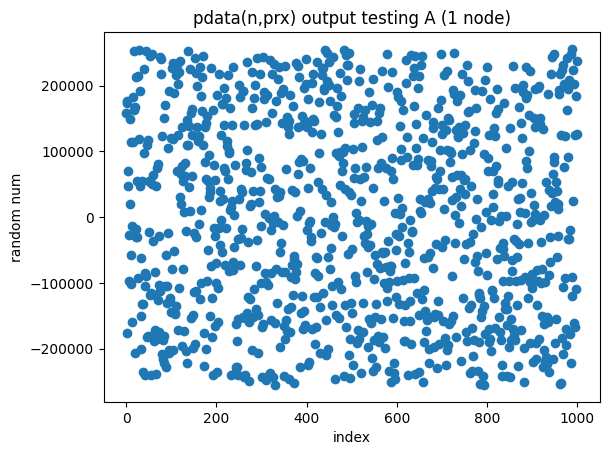

In [2]:
list=[]
with open('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/runlog1.txt', 'r') as file:
    # Iterate over each line in the file
    for line in file:
        # Strip leading and trailing whitespace
        line = line.strip()
        # Check if the stripped line starts with "rand_vec"
        if line.startswith('apdata(n,prx)'):
            # Split the line by spaces
            parts = line.split()
            list.append(float(parts[3]))
plt.scatter(np.arange(0,len(list)),np.array(list))
plt.xlabel('index')
plt.ylabel('random num')
plt.title('pdata(n,prx) output testing A (1 node)')

Text(0.5, 1.0, 'pdata(n,prx) output testing B (1 node)')

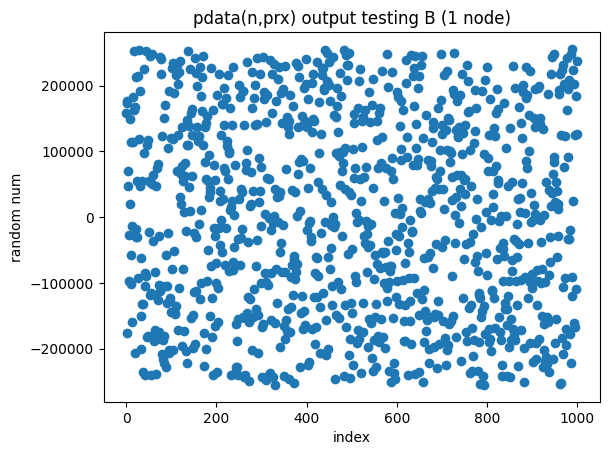

In [3]:
list=[]
with open('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/runlog1.txt', 'r') as file:
    # Iterate over each line in the file
    for line in file:
        # Strip leading and trailing whitespace
        line = line.strip()
        # Check if the stripped line starts with "rand_vec"
        if line.startswith('bpdata(n,prx)'):
            # Split the line by spaces
            parts = line.split()
            list.append(float(parts[3]))
plt.scatter(np.arange(0,len(list)),np.array(list))
plt.xlabel('index')
plt.ylabel('random num')
plt.title('pdata(n,prx) output testing B (1 node)')

Text(0.5, 1.0, 'pdata(n,prx) output testing C (1 node)')

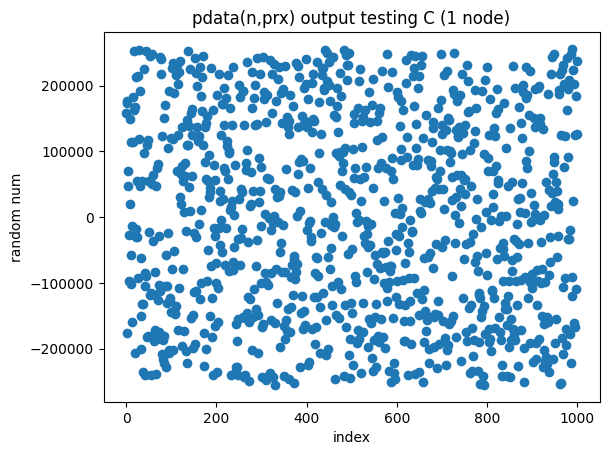

In [20]:
list=[]
with open('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/runlog1.txt', 'r') as file:
    # Iterate over each line in the file
    for line in file:
        # Strip leading and trailing whitespace
        line = line.strip()
        # Check if the stripped line starts with "rand_vec"
        if line.startswith('cpdata(n,prx)'):
            # Split the line by spaces
            parts = line.split()
            list.append(float(parts[3]))
plt.scatter(np.arange(0,len(list)),np.array(list))
plt.xlabel('index')
plt.ylabel('random num')
plt.title('pdata(n,prx) output testing C (1 node)')

Text(0.5, 1.0, 'pdata(n,prx) output testing E (1 node)')

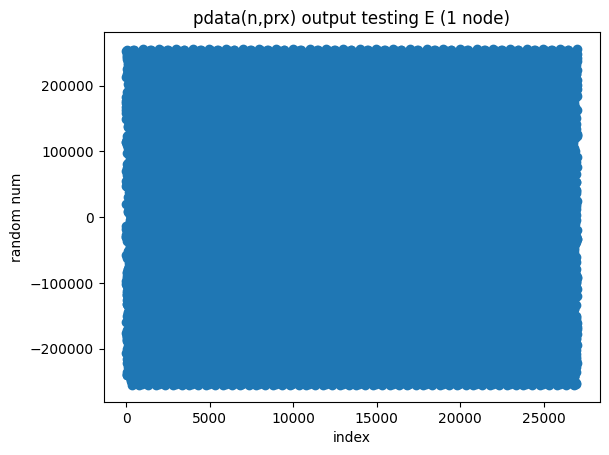

In [24]:
list=[]
with open('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/runlog1.txt', 'r') as file:
    # Iterate over each line in the file
    for line in file:
        # Strip leading and trailing whitespace
        line = line.strip()
        # Check if the stripped line starts with "rand_vec"
        if line.startswith('epdata(n,prx)'):
            # Split the line by spaces
            parts = line.split()
            list.append(float(parts[3]))
plt.scatter(np.arange(0,len(list)),np.array(list))
plt.xlabel('index')
plt.ylabel('random num')
plt.title('pdata(n,prx) output testing E (1 node)')

Text(0.5, 1.0, 'pdata(n,prx) output testing F (1 node)')

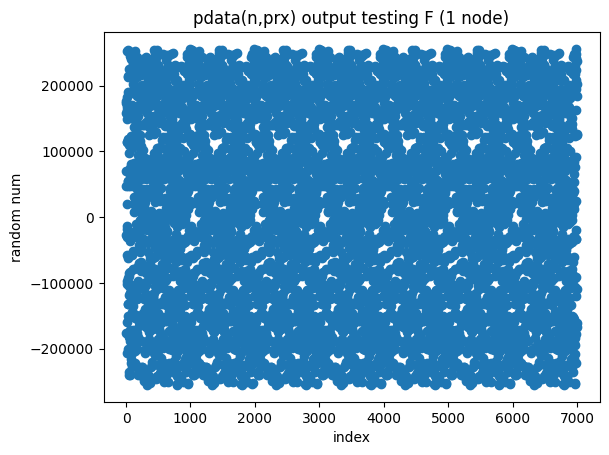

In [22]:
list=[]
with open('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/runlog1.txt', 'r') as file:
    # Iterate over each line in the file
    for line in file:
        # Strip leading and trailing whitespace
        line = line.strip()
        # Check if the stripped line starts with "rand_vec"
        if line.startswith('fpdata(n,prx)'):
            # Split the line by spaces
            parts = line.split()
            list.append(float(parts[3]))
plt.scatter(np.arange(0,len(list)),np.array(list))
plt.xlabel('index')
plt.ylabel('random num')
plt.title('pdata(n,prx) output testing F (1 node)')

Text(0.5, 1.0, 'initial output parcel locations (1 node)')

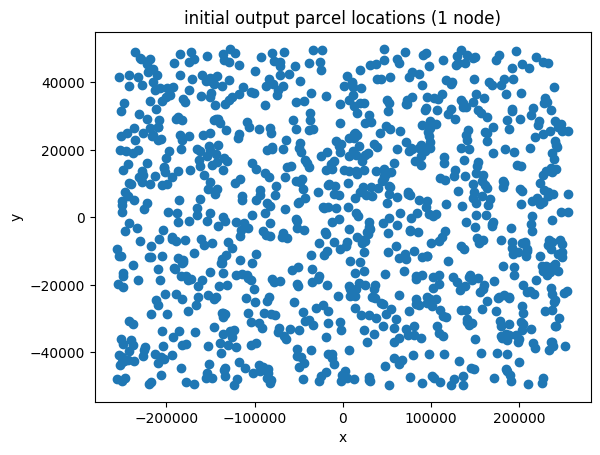

In [4]:
parcel=xr.open_dataset('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/cm1out_pdata_1.nc')
plt.scatter(parcel.isel(time=0)['x'].values, parcel.isel(time=0)['y'].values)
plt.xlabel('x')
plt.ylabel('y')
plt.title('initial output parcel locations (1 node)')

In [ ]:
#######################################################################################

Text(0.5, 1.0, 'pdata(n,prx) output testing A (16 node)')

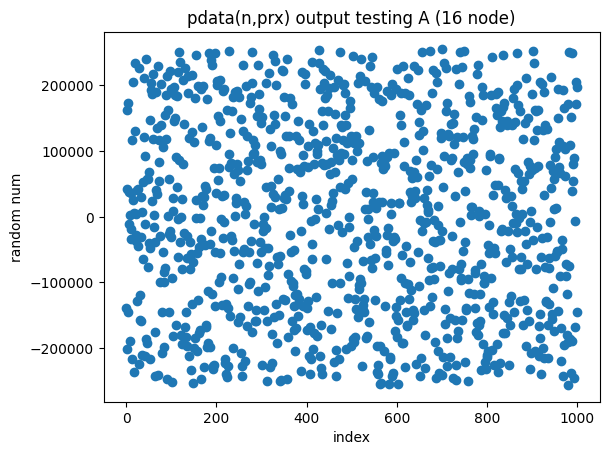

In [40]:
list=[]
with open('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/runlog16.txt', 'r') as file:
    # Iterate over each line in the file
    for line in file:
        # Strip leading and trailing whitespace
        line = line.strip()
        # Check if the stripped line starts with "rand_vec"
        if line.startswith('apdata(n,prx)'):
            # Split the line by spaces
            parts = line.split()
            list.append(float(parts[3]))
plt.scatter(np.arange(0,len(list)),np.array(list))
plt.xlabel('index')
plt.ylabel('random num')
plt.title('pdata(n,prx) output testing A (16 node)')

Text(0.5, 1.0, 'pdata(n,prx) output testing B (16 node)')

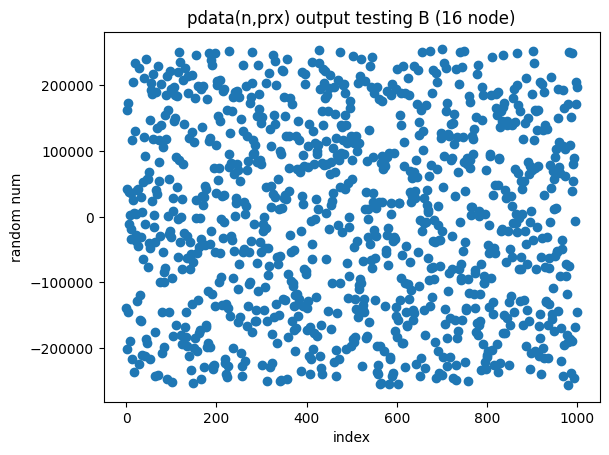

In [41]:
list=[]
with open('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/runlog16.txt', 'r') as file:
    # Iterate over each line in the file
    for line in file:
        # Strip leading and trailing whitespace
        line = line.strip()
        # Check if the stripped line starts with "rand_vec"
        if line.startswith('bpdata(n,prx)'):
            # Split the line by spaces
            parts = line.split()
            list.append(float(parts[3]))
plt.scatter(np.arange(0,len(list)),np.array(list))
plt.xlabel('index')
plt.ylabel('random num')
plt.title('pdata(n,prx) output testing B (16 node)')

Text(0.5, 1.0, 'pdata(n,prx) output testing C (16 node)')

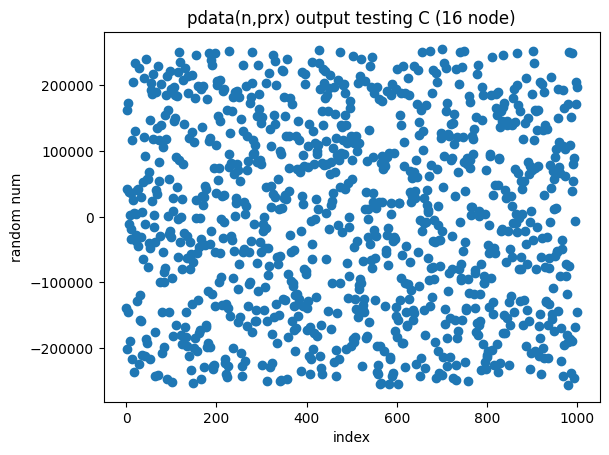

In [42]:
list=[]
with open('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/runlog16.txt', 'r') as file:
    # Iterate over each line in the file
    for line in file:
        # Strip leading and trailing whitespace
        line = line.strip()
        # Check if the stripped line starts with "rand_vec"
        if line.startswith('cpdata(n,prx)'):
            # Split the line by spaces
            parts = line.split()
            list.append(float(parts[3]))
plt.scatter(np.arange(0,len(list)),np.array(list))
plt.xlabel('index')
plt.ylabel('random num')
plt.title('pdata(n,prx) output testing C (16 node)')

Text(0.5, 1.0, 'pdata(n,prx) output testing E (16 node)')

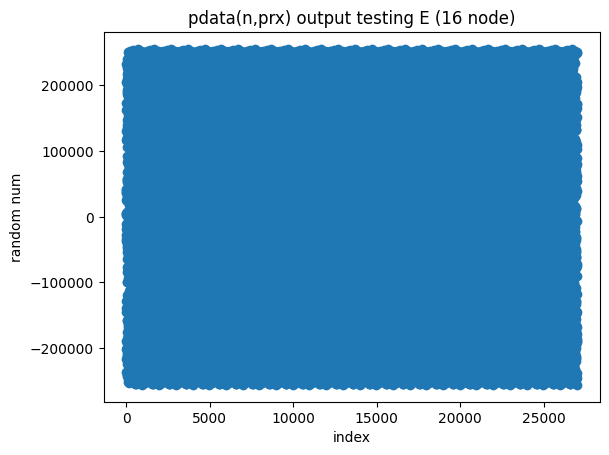

In [43]:
list=[]
with open('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/runlog16.txt', 'r') as file:
    # Iterate over each line in the file
    for line in file:
        # Strip leading and trailing whitespace
        line = line.strip()
        # Check if the stripped line starts with "rand_vec"
        if line.startswith('epdata(n,prx)'):
            # Split the line by spaces
            parts = line.split()
            list.append(float(parts[3]))
plt.scatter(np.arange(0,len(list)),np.array(list))
plt.xlabel('index')
plt.ylabel('random num')
plt.title('pdata(n,prx) output testing E (16 node)')

Text(0.5, 1.0, 'pdata(n,prx) output testing F (16 node)')

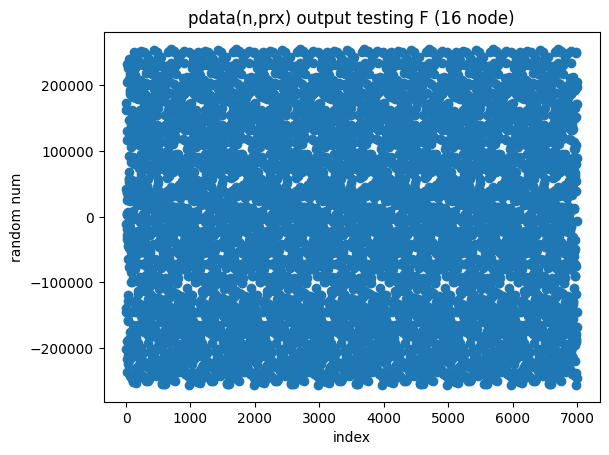

In [44]:
list=[]
with open('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/runlog16.txt', 'r') as file:
    # Iterate over each line in the file
    for line in file:
        # Strip leading and trailing whitespace
        line = line.strip()
        # Check if the stripped line starts with "rand_vec"
        if line.startswith('fpdata(n,prx)'):
            # Split the line by spaces
            parts = line.split()
            list.append(float(parts[3]))
plt.scatter(np.arange(0,len(list)),np.array(list))
plt.xlabel('index')
plt.ylabel('random num')
plt.title('pdata(n,prx) output testing F (16 node)')

Text(0.5, 1.0, 'initial output parcel locations (16 node)')

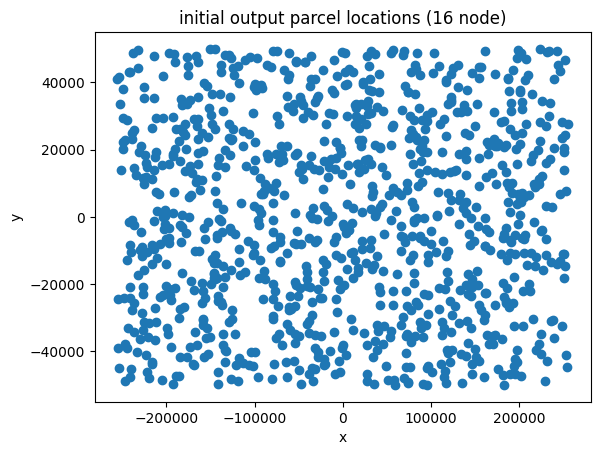

In [53]:
parcel=xr.open_dataset('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/cm1out_pdata_16.nc')
plt.scatter(parcel.isel(time=1)['x'].values,parcel.isel(time=1)['y'].values)
plt.xlabel('x')
plt.ylabel('y')
plt.title('initial output parcel locations (16 node)')